<a href="https://colab.research.google.com/github/aapaul29/Distance-Recognition-SML1-/blob/aaryan-workspace/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SML Project 1**

This notebook works in both **VS Code (local)** and **Google Colab**.

## **1. <u>Environment Detection & Setup</u>**

In [30]:
import sys
import os

IN_COLAB = 'google.colab' in sys.modules
print(f"Running in {'Google Colab' if IN_COLAB else 'VS Code / local'}")


Running in VS Code / local




## **2. <u>Google Colab: Mount Drive & Navigate to Project</u>**
This cell only runs on Colab. Adjust `COLAB_PROJECT_PATH` to where you uploaded the project folder in your Google Drive.

In [ ]:
# ---------------------------------------------------------------
# COLAB ONLY — skip if running locally
# Adjust this path to match your Google Drive folder structure.
COLAB_PROJECT_PATH = "/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-"
# ---------------------------------------------------------------

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd "$COLAB_PROJECT_PATH"
    print(f"Working directory: {os.getcwd()}")

    # Unzip data if not already extracted
    data_zip = os.path.join(COLAB_PROJECT_PATH, "data.zip")
    data_dir = os.path.join(COLAB_PROJECT_PATH, "data")
    if os.path.exists(data_zip) and not os.path.exists(data_dir):
        print("Unzipping data...")
        os.makedirs(data_dir, exist_ok=True)
        !unzip -q $data_zip -d $data_dir
        print("Done.")
    else:
        print("Data directory already exists or no zip found — skipping unzip.")
else:
    print("Local environment — no mounting needed.")

Mounted at /content/drive
/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-
Working directory: /content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-
Data directory already exists or no zip found — skipping unzip.


## **3. <u>Auto-reload & Imports**</u>

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score


from utils import load_config, load_dataset, load_test_dataset, print_results, save_results

# Add further sklearn imports here as needed.
# Note: SVRs are NOT allowed in this project.

config = load_config()

[INFO]: Configs are loaded with: 
 {'data_dir': WindowsPath('data'), 'load_rgb': False, 'downsample_factor': 10}


In [ ]:
if IN_COLAB:
    import shutil
    from pathlib import Path
    src = "/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-/data"
    dst = "/content/data"
    if not Path(dst).exists():
        print("Copying data to local Colab storage (faster I/O)...")
        shutil.copytree(src, dst)
        print("Done.")
    else:
        print("Local data already exists — skipping copy.")
    config["data_dir"] = Path(dst)

Local data already exists — skipping copy.


In [32]:
images, distances = load_dataset(config, split="train")
print(f"[INFO]: Dataset loaded with {len(images)} samples.")
print(f"[INFO]: Feature dimensionality: {images.shape[1]}")
print(f"Images shape : {images.shape}")
print(f"Distances shape: {distances.shape}")
print(f"Distance range : {distances.min():.2f} m – {distances.max():.2f} m")

[INFO]: Dataset loaded with 3000 samples.
[INFO]: Feature dimensionality: 900
Images shape : (3000, 900)
Distances shape: (3000,)
Distance range : 0.25 m – 2.78 m


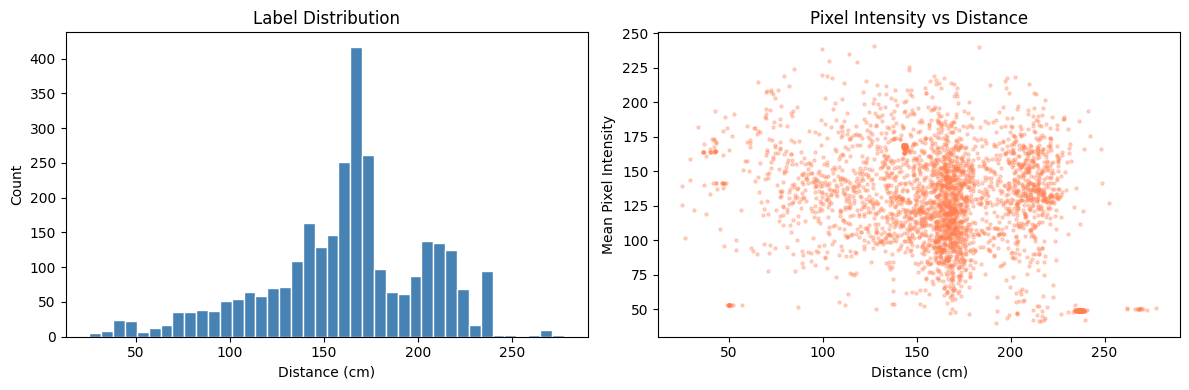

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label distribution
axes[0].hist(distances * 100, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Distance (cm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Label Distribution')

# Mean pixel intensity vs distance
mean_intensity = images.mean(axis=1)
axes[1].scatter(distances * 100, mean_intensity, alpha=0.3, s=5, color='coral')
axes[1].set_xlabel('Distance (cm)')
axes[1].set_ylabel('Mean Pixel Intensity')
axes[1].set_title('Pixel Intensity vs Distance')

plt.tight_layout()
plt.show()

## **4. <u>ML Model Implementation**</u>
Implement preprocessing, model training, data split and evaluation.

**4.1. <u>Creating Splits</u>**

train (70%) | val (15%) | test (15%)
Why three splits?
         

* train  → the model learns from this
* val    → we tune hyperparameters on this (never used for fitting)
* test   → final local evaluation; simulates the private Kaggle set
* random_state=42 keeps the split identical every run (reproducibility)




         
    
      

In [34]:
# First split off the test set (15 %)
X_trainval, X_test, y_trainval, y_test = train_test_split(
        images, distances,
        test_size=0.15,
        random_state=42)

# Then split the remaining 85 % into train (≈70 %) and val (≈15 %)
# 0.15 / 0.85 ≈ 0.176  →  gives us ~15 % of the total as validation
X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=0.176,
        random_state=42)

print(f"[INFO]: Split sizes — train: {len(X_train)}, "
          f"val: {len(X_val)}, test: {len(X_test)}")

[INFO]: Split sizes — train: 2101, val: 449, test: 450


In [35]:
# ── Preprocessing ────────────────────────────────────────────────────────────
N_COMPONENTS = 100 ## tune this {50, 100, 150, 200}

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train only
X_val_scaled   = scaler.transform(X_val)          # transform only
X_test_scaled  = scaler.transform(X_test)         # transform only

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"[INFO]: Scaling done.")
print(f"        Feature mean (train, first 5): {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"        Feature std  (train, first 5): {X_train_scaled.std(axis=0)[:5].round(4)}")

explained = pca.explained_variance_ratio_.cumsum()[-1] * 100
print(f"PCA with {N_COMPONENTS} components explains {explained:.1f}% of variance")
print(f"Reduced feature shape: {X_train_pca.shape}")

[INFO]: Scaling done.
        Feature mean (train, first 5): [-0.  0. -0. -0.  0.]
        Feature std  (train, first 5): [1. 1. 1. 1. 1.]
PCA with 100 components explains 95.4% of variance
Reduced feature shape: (2101, 100)


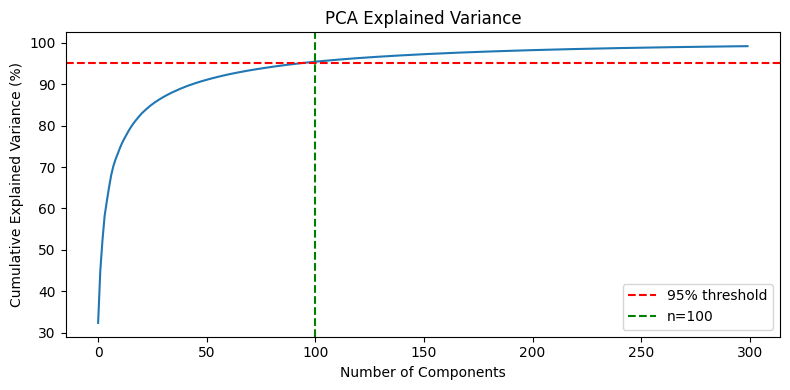

In [36]:
# Plot cumulative explained variance to help choose n_components
pca_full = PCA(n_components=min(300, X_train_scaled.shape[1]), random_state=42)
pca_full.fit(X_train_scaled)

cum_var = pca_full.explained_variance_ratio_.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(cum_var * 100)
plt.axhline(95, color='red', linestyle='--', label='95% threshold')
plt.axvline(N_COMPONENTS, color='green', linestyle='--', label=f'n={N_COMPONENTS}')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
#Model definition & training
## Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_pca, y_train)

val_pred_ridge = ridge.predict(X_val_pca)
mae_ridge = mean_absolute_error(y_val, val_pred_ridge) * 100
print(f"Ridge  — Val MAE: {mae_ridge:.2f} cm")

Ridge  — Val MAE: 27.03 cm


In [39]:
# Main Model
hgbr = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.03,
    max_depth=6,
    min_samples_leaf=10,
    l2_regularization=0.1,
    random_state=42,
)
hgbr.fit(X_train_pca, y_train)

val_pred_hgbr = hgbr.predict(X_val_pca)
mae_hgbr = mean_absolute_error(y_val, val_pred_hgbr) * 100
r2_hgbr  = r2_score(y_val, val_pred_hgbr) * 100
print(f"HGBR  — Val MAE: {mae_hgbr:.2f} cm  |  R²: {r2_hgbr:.1f}%")

HGBR  — Val MAE: 18.46 cm  |  R²: 62.9%


In [41]:
## Hyperparameter Tuning
param_grid = {
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth':     [4, 6, 8, 10],
    'max_iter':      [400, 800, 1000],
    'min_samples_leaf': [5, 10, 20],
}

grid_search = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_pca, y_train)

print("Best params:", grid_search.best_params_)
best_hgbr = grid_search.best_estimator_

val_pred_best = best_hgbr.predict(X_val_pca)
mae_best = mean_absolute_error(y_val, val_pred_best) * 100
print(f"Tuned HGBR — Val MAE: {mae_best:.2f} cm")

Fitting 3 folds for each of 108 candidates, totalling 324 fits


KeyboardInterrupt: 

In [28]:
## Model Stacking

estimators = [
     ('hgbr', HistGradientBoostingRegressor(
         **grid_search.best_params_, random_state=42)),
     ('rf',   RandomForestRegressor(
         n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)),
]
stack = StackingRegressor(
     estimators=estimators,
     final_estimator=Ridge(),
     cv=5,
     n_jobs=-1,
)
stack.fit(X_train_pca, y_train)
 
val_pred_stack = stack.predict(X_val_pca)
mae_stack = mean_absolute_error(y_val, val_pred_stack) * 100
print(f"Stacking — Val MAE: {mae_stack:.2f} cm")

Stacking — Val MAE: 20.03 cm


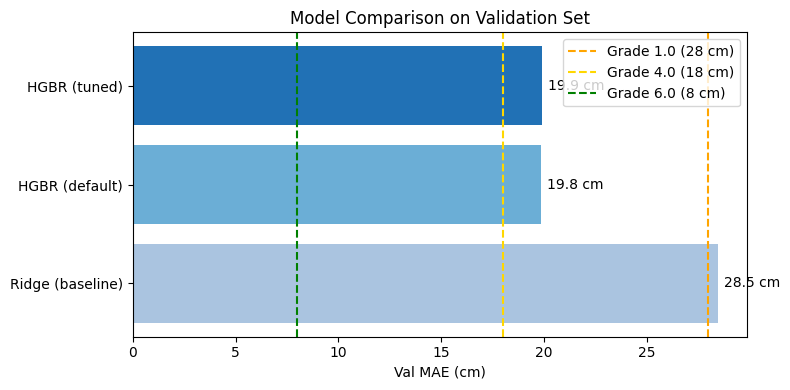

In [29]:
##Model Comparison 
results = {
    'Ridge (baseline)': mae_ridge,
    'HGBR (default)':   mae_hgbr,
    'HGBR (tuned)':     mae_best,
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(results.keys()), list(results.values()), color=['#aac4e0', '#6baed6', '#2171b5'])
ax.axvline(28, color='orange', linestyle='--', label='Grade 1.0 (28 cm)')
ax.axvline(18, color='gold',   linestyle='--', label='Grade 4.0 (18 cm)')
ax.axvline(8,  color='green',  linestyle='--', label='Grade 6.0 (8 cm)')
ax.set_xlabel('Val MAE (cm)')
ax.set_title('Model Comparison on Validation Set')
ax.legend()
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f} cm', va='center')
plt.tight_layout()
plt.show()

In [42]:
# Evaluation on training / validation set
# Swap best_hgbr for stack if stacking was better
final_model = best_hgbr

test_pred = final_model.predict(X_test_pca)
print("=== FINAL TEST SET RESULTS ===")
print_results(y_test, test_pred)


ValueError: X has 100 features, but HistGradientBoostingRegressor is expecting 300 features as input.

In [ ]:
# ── Retrain on full labelled dataset ─────────────────────────────────────────
X_all_scaled = scaler.fit_transform(images)         # refit scaler on all data
X_all_pca    = pca.fit_transform(X_all_scaled)      # refit PCA on all data

final_model.set_params(**grid_search.best_params_)  # keep best hyperparams
final_model.fit(X_all_pca, distances)
print("Final model retrained on full dataset")

# ── Load and transform Kaggle test images ────────────────────────────────────
kaggle_images = load_test_dataset(config)
kaggle_images = np.array(kaggle_images)

kaggle_scaled = scaler.transform(kaggle_images)
kaggle_pca    = pca.transform(kaggle_scaled)

kaggle_pred = final_model.predict(kaggle_pca)

save_results(kaggle_pred)
print(f"Saved prediction.csv with {len(kaggle_pred)} predictions")
print(f"Predicted distance range: {kaggle_pred.min():.2f} m – {kaggle_pred.max():.2f} m")

## 7. Predict on Test Set & Save

In [ ]:
test_images = load_test_dataset(config)
print(f"[INFO]: Test set loaded with {len(test_images)} samples.")

# TODO: Run your trained model on test_images
# test_pred = model.predict(...)

# save_results(test_pred)